In [1]:
!pip install flask pyngrok faker -q

import re, json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from faker import Faker
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries ready!")
print(f"   TensorFlow version: {tf.__version__}")


✅ All libraries ready!
   TensorFlow version: 2.20.0


In [2]:
fake = Faker()
Faker.seed(42)
np.random.seed(42)

# PII Patterns for labeling
PII_PATTERNS = {
    "EMAIL":        r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}',
    "PHONE":        r'\b(\+?\d{1,3}[\s.\-]?)?\(?\d{3}\)?[\s.\-]?\d{3}[\s.\-]?\d{4}\b',
    "SSN":          r'\b\d{3}-\d{2}-\d{4}\b',
    "CREDIT_CARD":  r'\b(?:\d{4}[\- ]?){3}\d{4}\b',
    "IP_ADDRESS":   r'\b(?:\d{1,3}\.){3}\d{1,3}\b',
}

MASK_MAP = {
    "EMAIL":       "[EMAIL REDACTED]",
    "PHONE":       "[PHONE REDACTED]",
    "SSN":         "[SSN REDACTED]",
    "CREDIT_CARD": "[CARD REDACTED]",
    "IP_ADDRESS":  "[IP REDACTED]",
}

def detect_pii_regex(text):
    found = []
    for pii_type, pattern in PII_PATTERNS.items():
        if re.search(pattern, str(text)):
            found.append(pii_type)
    return found

def mask_pii(text):
    text = str(text)
    for pii_type, pattern in PII_PATTERNS.items():
        text = re.sub(pattern, MASK_MAP[pii_type], text)
    return text

# Generate PII texts
pii_texts = []
for _ in range(400):
    choice = np.random.randint(0, 5)
    if choice == 0:
        pii_texts.append(f"My email is {fake.email()} please contact me")
    elif choice == 1:
        pii_texts.append(f"Call me at {fake.phone_number()} anytime")
    elif choice == 2:
        pii_texts.append(f"My SSN is {fake.ssn()} for verification")
    elif choice == 3:
        pii_texts.append(f"Card number {fake.credit_card_number()} expires soon")
    else:
        pii_texts.append(f"Server IP is {fake.ipv4()} check logs")

# Generate clean (non-PII) texts
clean_texts = []
clean_samples = [
    "The weather is sunny today",
    "I love machine learning and AI",
    "The project deadline is next week",
    "Please review the attached document",
    "The meeting is scheduled for Monday",
    "TensorFlow is a great deep learning framework",
    "The satellite images show green vegetation",
    "Flask is used to build REST APIs",
    "Data privacy is important in AI systems",
    "The model accuracy improved after tuning",
]
for _ in range(400):
    clean_texts.append(np.random.choice(clean_samples) + " " + fake.sentence())

# Build dataframe
texts  = pii_texts + clean_texts
labels = ["PII"] * 400 + ["NOT_PII"] * 400

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Add masked text and PII types columns
df["pii_types"]   = df["text"].apply(detect_pii_regex)
df["masked_text"] = df["text"].apply(mask_pii)

print(f"✅ Dataset generated!")
print(f"   Total rows : {len(df)}")
print(f"   PII rows   : {sum(df['label']=='PII')}")
print(f"   Clean rows : {sum(df['label']=='NOT_PII')}")
print()
df.head(6)


✅ Dataset generated!
   Total rows : 800
   PII rows   : 400
   Clean rows : 400



,text,label,pii_types,masked_text
0,I love machine learning and AI Our piece playe...,NOT_PII,[],I love machine learning and AI Our piece playe...
1,The project deadline is next week Purpose star...,NOT_PII,[],The project deadline is next week Purpose star...
2,Call me at 563.320.1632x8708 anytime,PII,[],Call me at 563.320.1632x8708 anytime
3,The satellite images show green vegetation Fea...,NOT_PII,[],The satellite images show green vegetation Fea...
4,Call me at 958-812-2362x31665 anytime,PII,[],Call me at 958-812-2362x31665 anytime
5,I love machine learning and AI Board populatio...,NOT_PII,[],I love machine learning and AI Board populatio...


In [3]:
# ── Encode labels ──
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])  # NOT_PII=0, PII=1
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# ── Tokenize text using TF TextVectorization ──
MAX_TOKENS  = 5000
MAX_LEN     = 50
EMBED_DIM   = 32

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
vectorizer.adapt(df["text"].values)

# ── Train / Test split ──
X_train, X_test, y_train, y_test = train_test_split(
    df["text"].values, df["label_enc"].values,
    test_size=0.2, random_state=42
)

print(f"\nTrain size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")


Label encoding: {'NOT_PII': np.int64(0), 'PII': np.int64(1)}

Train size : 640
Test size  : 160


In [4]:
# ── Build TensorFlow Model ──
model = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    layers.Embedding(MAX_TOKENS, EMBED_DIM, mask_zero=True),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')   # Binary: PII or NOT_PII
], name="PII_Classifier")

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "PII_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 50)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,225 (641.50 KB)

 Trainable params: 164,225 (641.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ── Train the Model ──
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ── Evaluate ──
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Model trained!")
print(f"   Test Accuracy : {acc*100:.2f}%")
print(f"   Test Loss     : {loss:.4f}")


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8663 - loss: 0.6818 - val_accuracy: 1.0000 - val_loss: 0.6567
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9983 - loss: 0.6059 - val_accuracy: 1.0000 - val_loss: 0.5205
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.4097 - val_accuracy: 1.0000 - val_loss: 0.2620
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.1651 - val_accuracy: 1.0000 - val_loss: 0.0732
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0469 - val_accuracy: 1.0000 - val_loss: 0.0169
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0134 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - v

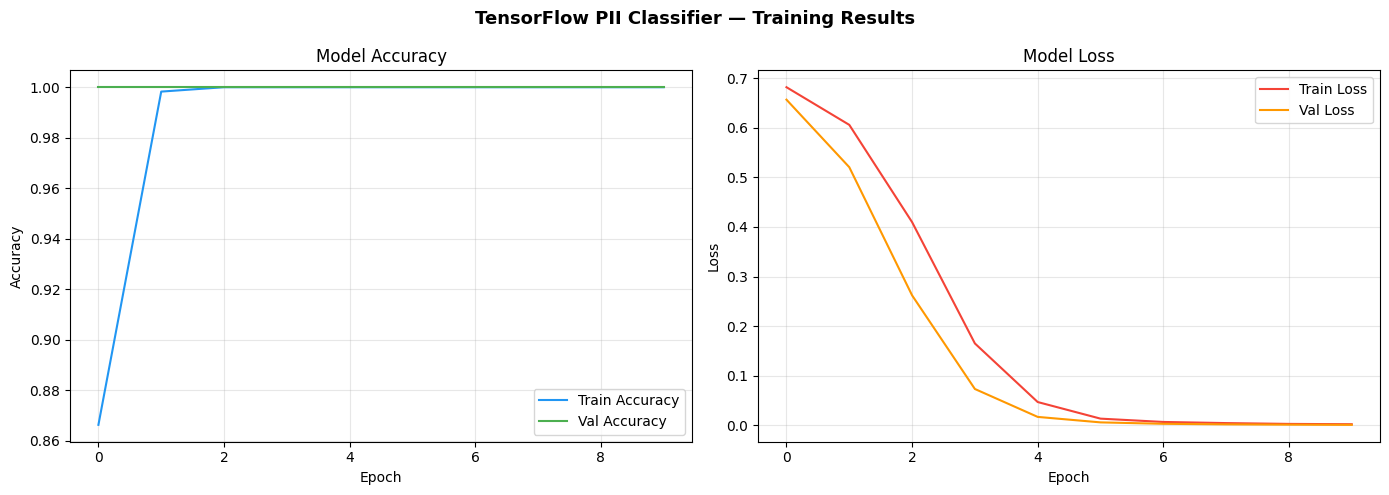

✅ Training charts saved!


In [6]:
# ── Plot Training History ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("TensorFlow PII Classifier — Training Results", fontsize=13, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#4CAF50')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='#F44336')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#FF9800')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tf_training.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training charts saved!")


In [7]:
# ── Save the trained model ──
model.save("pii_tf_model.keras")
print("✅ Model saved to: pii_tf_model.keras")

✅ Model saved to: pii_tf_model.keras


In [8]:
# ── Get Ngrok token ──
from pyngrok import ngrok

NGROK_TOKEN = "3FTd8Xle8HYi1Yh4Zr9ja3pJorY_3mk8Li5F5qptp5mCKQSHU"
ngrok.set_auth_token(NGROK_TOKEN)
print("✅ Ngrok ready!")


✅ Ngrok ready!


In [9]:
from flask import Flask, request, jsonify
import datetime

app = Flask(__name__)

# Load saved model
tf_model = keras.models.load_model("pii_tf_model.keras")
print("✅ TensorFlow model loaded into Flask!")

def get_risk(prob):
    if prob >= 0.8:   return "HIGH"
    elif prob >= 0.5: return "MEDIUM"
    elif prob >= 0.3: return "LOW"
    else:             return "NONE"

# ── Route 1: Home ──
@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "status":  "running",
        "api":     "TensorFlow PII Detection API",
        "model":   "PII Text Classifier (TensorFlow)",
        "version": "1.0",
        "endpoints": {
            "GET  /":         "API status",
            "POST /predict":  "Predict PII probability using TF model",
            "POST /mask":     "Detect + Mask PII in text",
            "POST /analyze":  "Full analysis — TF prediction + regex + masking"
        }
    })

# ── Route 2: /predict — TF model prediction ──
@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    if not data or "text" not in data:
        return jsonify({"error": "Send JSON with 'text' field"}), 400

    text  = data["text"]
    prob  = float(tf_model.predict(tf.constant([text]), verbose=0)[0][0])
    label = "PII" if prob >= 0.5 else "NOT_PII"
    risk  = get_risk(prob)

    return jsonify({
        "text":            text,
        "prediction":      label,
        "pii_probability": round(prob, 4),
        "risk_level":      risk
    })

# ── Route 3: /mask — Mask PII in text ──
@app.route("/mask", methods=["POST"])
def mask():
    data = request.get_json()
    if not data or "text" not in data:
        return jsonify({"error": "Send JSON with 'text' field"}), 400

    text        = data["text"]
    masked      = mask_pii(text)
    pii_types   = detect_pii_regex(text)
    prob        = float(tf_model.predict(tf.constant([text]), verbose=0)[0][0])
    return jsonify({
        "original_text": text,
        "masked_text":   masked,
        "pii_types":     pii_types,
        "pii_probability": round(prob, 4)
    })

# ── Route 4: /analyze — Full analysis ──
@app.route("/analyze", methods=["POST"])
def analyze():
    data = request.get_json()
    if not data or "text" not in data:
        return jsonify({"error": "Send JSON with 'text' field"}), 400

    text      = data["text"]
    prob      = float(tf_model.predict(tf.constant([text]), verbose=0)[0][0])
    label     = "PII" if prob >= 0.5 else "NOT_PII"
    risk      = get_risk(prob)
    pii_types = detect_pii_regex(text)
    masked    = mask_pii(text)

    advice_map = {
        "HIGH":   "Immediate action — highly sensitive PII detected",
        "MEDIUM": "Review recommended — moderately sensitive PII",
        "LOW":    "Low risk — minor identifiers found",
        "NONE":   "Text appears safe — no PII detected"
    }

    return jsonify({
        "timestamp":       datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "original_text":   text,
        "masked_text":     masked,
        "tf_prediction":   label,
        "pii_probability": round(prob, 4),
        "risk_level":      risk,
        "advice":          advice_map[risk],
        "pii_types_found": pii_types
    })

print("✅ Flask routes defined!")


✅ TensorFlow model loaded into Flask!
✅ Flask routes defined!


In [10]:
import threading

def run_flask():
    app.run(port=5000, use_reloader=False, debug=False)

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

public_url = ngrok.connect(5000)
print("=" * 55)
print("✅ TensorFlow Flask PII API is LIVE!")
print(f"   Public URL : {public_url}")
print(f"   Predict    : {public_url}/predict")
print(f"   Mask       : {public_url}/mask")
print(f"   Analyze    : {public_url}/analyze")
print("=" * 55)


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


✅ TensorFlow Flask PII API is LIVE!
   Public URL : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"
   Predict    : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/predict
   Mask       : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/mask
   Analyze    : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/analyze


In [11]:
import requests, json

# Test 1: Home
print("TEST 1: Home")
print("-"*45)
res = requests.get("http://localhost:5000/")
print(json.dumps(res.json(), indent=2))


INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:07] "GET / HTTP/1.1" 200 -


TEST 1: Home
---------------------------------------------
{
  "api": "TensorFlow PII Detection API",
  "endpoints": {
    "GET  /": "API status",
    "POST /analyze": "Full analysis \u2014 TF prediction + regex + masking",
    "POST /mask": "Detect + Mask PII in text",
    "POST /predict": "Predict PII probability using TF model"
  },
  "model": "PII Text Classifier (TensorFlow)",
  "status": "running",
  "version": "1.0"
}


In [12]:
# Test 2: Predict
print("TEST 2: /predict")
print("-"*45)
payload = {"text": "My SSN is 123-45-6789 and email is john@gmail.com"}
res = requests.post("http://localhost:5000/predict", json=payload)
print(json.dumps(res.json(), indent=2))


TEST 2: /predict
---------------------------------------------


INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:08] "POST /predict HTTP/1.1" 200 -


{
  "pii_probability": 0.9931,
  "prediction": "PII",
  "risk_level": "HIGH",
  "text": "My SSN is 123-45-6789 and email is john@gmail.com"
}


In [13]:
# Test 3: Mask
print("TEST 3: /mask")
print("-"*45)
payload = {"text": "Call me at 555-234-5678 or email alice@company.com"}
res = requests.post("http://localhost:5000/mask", json=payload)
print(json.dumps(res.json(), indent=2))


INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:12] "POST /mask HTTP/1.1" 200 -


TEST 3: /mask
---------------------------------------------
{
  "masked_text": "Call me at [PHONE REDACTED] or email [EMAIL REDACTED]",
  "original_text": "Call me at 555-234-5678 or email alice@company.com",
  "pii_probability": 0.9957,
  "pii_types": [
    "EMAIL",
    "PHONE"
  ]
}


In [14]:
# Test 4: Full Analyze
print("TEST 4: /analyze")
print("-"*45)
payload = {"text": "Patient card 4111-1111-1111-1111, IP 192.168.1.1, email p@hospital.com"}
res = requests.post("http://localhost:5000/analyze", json=payload)
print(json.dumps(res.json(), indent=2))


INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:13] "POST /analyze HTTP/1.1" 200 -


TEST 4: /analyze
---------------------------------------------
{
  "advice": "Immediate action \u2014 highly sensitive PII detected",
  "masked_text": "Patient card [CARD REDACTED], IP [IP REDACTED], email [EMAIL REDACTED]",
  "original_text": "Patient card 4111-1111-1111-1111, IP 192.168.1.1, email p@hospital.com",
  "pii_probability": 0.9866,
  "pii_types_found": [
    "EMAIL",
    "CREDIT_CARD",
    "IP_ADDRESS"
  ],
  "risk_level": "HIGH",
  "tf_prediction": "PII",
  "timestamp": "2026-06-23 05:11:13"
}


In [15]:
# Test 5: Multiple texts — results table
test_texts = [
    "The weather is sunny today",
    "My email is sarah@example.com",
    "SSN: 987-65-4321 and phone 800-555-1234",
    "IP address is 10.0.0.1",
    "Card 4111-1111-1111-1111, email john@test.com, SSN 111-22-3333",
    "The meeting is scheduled for tomorrow",
    "Contact: jane@company.org, Phone: 415-555-9876",
]

results = []
for text in test_texts:
    res = requests.post("http://localhost:5000/analyze", json={"text": text}).json()
    results.append({
        "Text":        text[:45] + "..." if len(text) > 45 else text,
        "Prediction":  res["tf_prediction"],
        "PII Prob":    res["pii_probability"],
        "Risk":        res["risk_level"],
        "PII Types":   ", ".join(res["pii_types_found"]) or "None"
    })

df_results = pd.DataFrame(results)
print("\nAPI TEST RESULTS (TensorFlow Model)")
print("="*80)
print(df_results.to_string(index=False))


INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:15] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:15] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:15] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:15] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:15] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:15] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [23/Jun/2026 05:11:15] "POST /analyze HTTP/1.1" 200 -



API TEST RESULTS (TensorFlow Model)
                                            Text Prediction  PII Prob Risk               PII Types
                      The weather is sunny today    NOT_PII    0.0000 NONE                    None
                   My email is sarah@example.com        PII    0.9993 HIGH                   EMAIL
         SSN: 987-65-4321 and phone 800-555-1234    NOT_PII    0.1776 NONE              PHONE, SSN
                          IP address is 10.0.0.1        PII    0.9030 HIGH              IP_ADDRESS
Card 4111-1111-1111-1111, email john@test.com...        PII    0.9933 HIGH EMAIL, SSN, CREDIT_CARD
           The meeting is scheduled for tomorrow    NOT_PII    0.0002 NONE                    None
Contact: jane@company.org, Phone: 415-555-987...        PII    0.8515 HIGH            EMAIL, PHONE


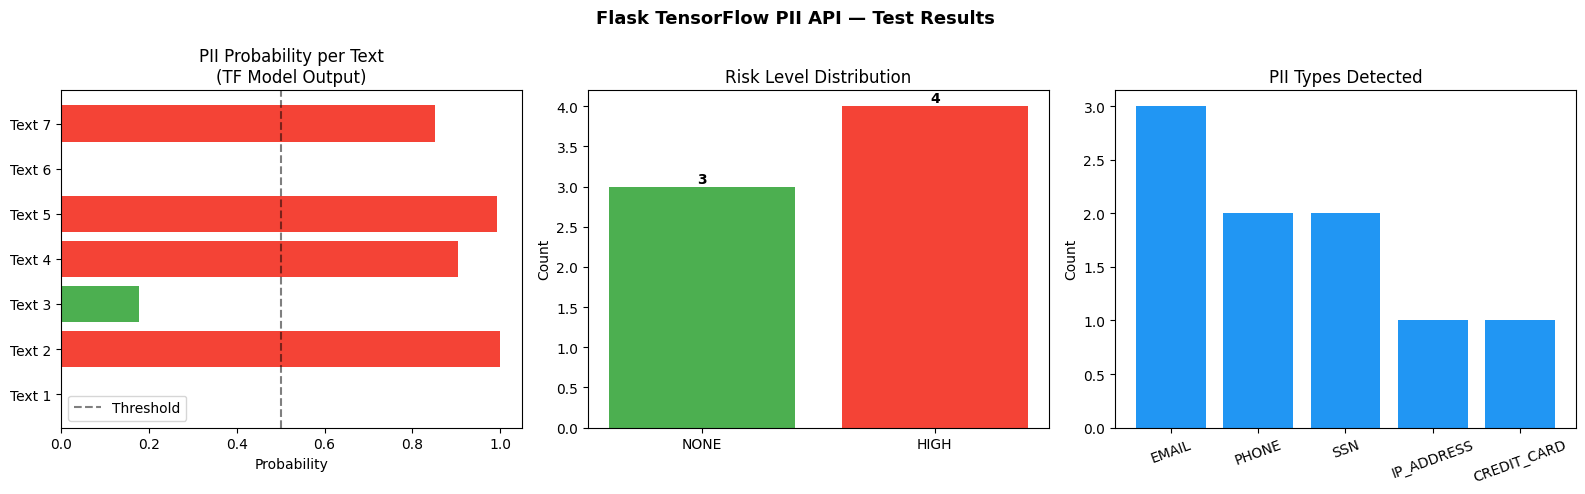

✅ Charts saved!


In [18]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Flask TensorFlow PII API — Test Results", fontsize=13, fontweight='bold')

probs       = [r["PII Prob"] for r in results]
risk_levels = [r["Risk"] for r in results]
all_types   = []
for r in results:
    if r["PII Types"] != "None":
        all_types.extend(r["PII Types"].split(", "))

# 1. PII Probability per text
axes[0].barh(range(len(test_texts)),probs,
             color=['#F44336' if p>=0.5 else '#4CAF50' for p in probs])
axes[0].set_title('PII Probability per Text\n(TF Model Output)')
axes[0].set_xlabel('Probability')
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
axes[0].set_yticks(range(len(test_texts)))
axes[0].set_yticklabels([f"Text {i+1}" for i in range(len(test_texts))])
axes[0].legend()

# 2. Risk distribution
risk_counts = Counter(risk_levels)
colors_map  = {'HIGH':'#F44336','MEDIUM':'#FF9800','LOW':'#FFC107','NONE':'#4CAF50'}
axes[1].bar(risk_counts.keys(), risk_counts.values(),
            color=[colors_map.get(r,'#9E9E9E') for r in risk_counts.keys()])
axes[1].set_title('Risk Level Distribution')
axes[1].set_ylabel('Count')
for i,(k,v) in enumerate(risk_counts.items()):
    axes[1].text(i, v+0.05, str(v), ha='center', fontweight='bold')

# 3. PII types found
if all_types:
    tc = Counter(all_types)
    axes[2].bar(tc.keys(), tc.values(), color='#2196F3')
    axes[2].set_title('PII Types Detected')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=20)
else:
    axes[2].text(0.5,0.5,'No PII types\ndetected',ha='center',va='center',
                 transform=axes[2].transAxes, color='green', fontsize=12)
    axes[2].set_title('PII Types Detected')

plt.tight_layout()
plt.savefig("flask_tf_api_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")


## ✅ Summary

### What We Built:
| Component | Detail |
|-----------|--------|
| Dataset | 800 rows fake PII (Faker library) |
| TF Model | Embedding + Dense layers, binary classifier |
| Model Output | PII probability (0 to 1) |
| Flask Routes | `/`, `/predict`, `/mask`, `/analyze` |
| PII Detection | TF model + Regex combined |
| Public Access | Ngrok URL |

